In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")

# Class names for Fashion MNIST
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

TensorFlow version: 2.20.0


In [2]:
# Load Fashion MNIST — built into Keras, no download needed
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Training images shape : {X_train.shape}")
print(f"Testing  images shape : {X_test.shape}")
print(f"Training labels shape : {y_train.shape}")
print(f"Pixel value range     : {X_train.min()} to {X_train.max()}")
print(f"Number of classes     : {len(np.unique(y_train))}")
print(f"\nClass distribution:")
for i, name in enumerate(class_names):
    print(f"  Class {i} ({name:12s}): {np.sum(y_train == i)} samples")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape : (60000, 28, 28)
Testing  images shape : (10000, 28, 28)
Training labels shape : (60000,)
Pixel value range     : 0 to 255
Number of classes     : 10

Class distribution:
  Class 0 (T-shirt/top ): 6000 samples
  Class 1 (Trouser     ): 6000 samples
  Class 2 (Pullover    ): 6000 samples
  Class 3 (Dress       ): 6000 samples
  Class 4 (Coat        ): 6000 samples
  Class 5 (Sandal      ): 6000 samples
  Class 6 (Shirt       ): 6000 samples
  Class 7 (Sneaker     ): 6000 samples
  Class 8 (Bag         ): 6000 samples
  Class 9 (Ankle boot  ): 6000 samples


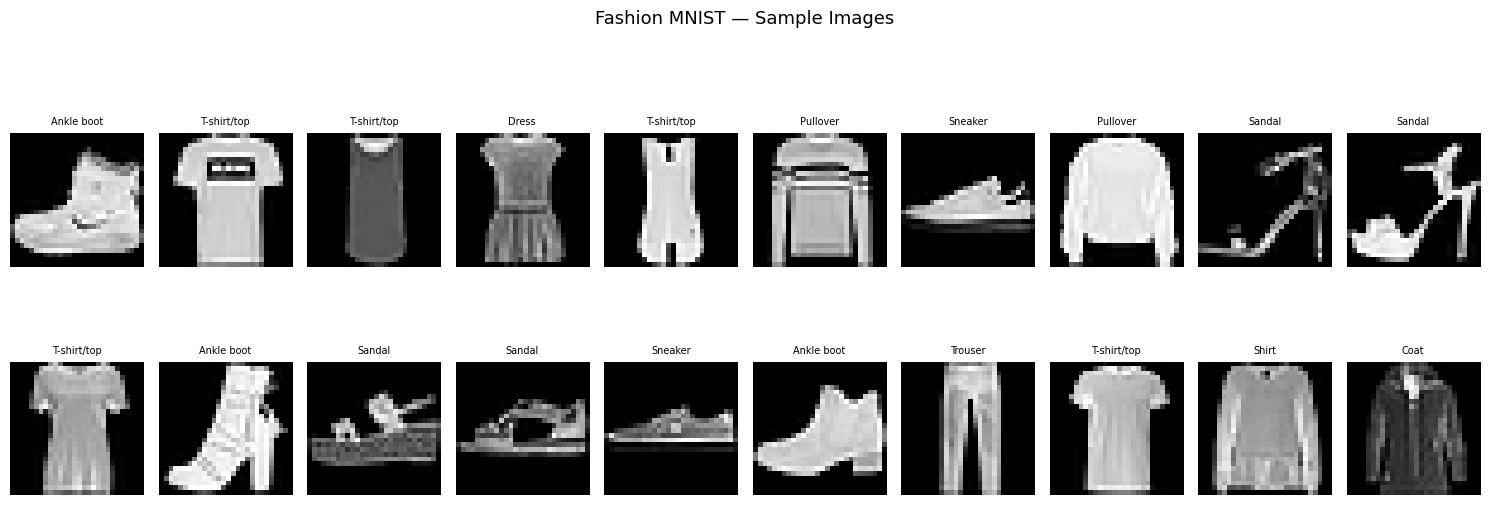

In [3]:
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=7)
    plt.axis("off")

plt.suptitle("Fashion MNIST — Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Flatten 28x28 images to 784-dimensional vectors (for Dense layers)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# One-hot encode labels (10 classes)
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print(f"X_train shape after flattening : {X_train_flat.shape}")
print(f"X_test  shape after flattening : {X_test_flat.shape}")
print(f"y_train shape after encoding   : {y_train_cat.shape}")
print(f"\nSample one-hot encoded label:")
print(f"  Original label : {y_train[0]} ({class_names[y_train[0]]})")
print(f"  One-hot vector : {y_train_cat[0]}")

X_train shape after flattening : (60000, 784)
X_test  shape after flattening : (10000, 784)
y_train shape after encoding   : (60000, 10)

Sample one-hot encoded label:
  Original label : 9 (Ankle boot)
  One-hot vector : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [5]:
# Build DNN architecture
model = Sequential([
    # Input layer — 784 input features (28x28 flattened)
    Dense(512, activation="relu", input_shape=(784,)),
    Dropout(0.3),    # randomly drop 30% neurons to prevent overfitting

    # Hidden Layer 2
    Dense(256, activation="relu"),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(128, activation="relu"),
    Dropout(0.2),

    # Output Layer — 10 neurons for 10 classes, softmax for probabilities
    Dense(10, activation="softmax")
])

# Display architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # multi-class loss
    metrics=["accuracy"]
)

# EarlyStopping — stop training when validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",   # watch validation loss
    patience=5,           # stop if no improvement for 5 epochs
    restore_best_weights=True  # revert to best weights when stopped
)

# Train model
history = model.fit(
    X_train_flat, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")
print(f"Final Training Accuracy  : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7752 - loss: 0.6192 - val_accuracy: 0.8505 - val_loss: 0.4181
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8377 - loss: 0.4460 - val_accuracy: 0.8587 - val_loss: 0.3881
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8528 - loss: 0.4065 - val_accuracy: 0.8616 - val_loss: 0.3763
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8611 - loss: 0.3837 - val_accuracy: 0.8692 - val_loss: 0.3603
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8646 - loss: 0.3660 - val_accuracy: 0.8717 - val_loss: 0.3573
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8691 - loss: 0.3511 - val_accuracy: 0.8798 - val_loss: 0.3371
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8755 - loss: 0.3392 - val_accuracy: 0.8762 - val_loss: 0.3376
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8811 - loss: 0.3277 - val_ac

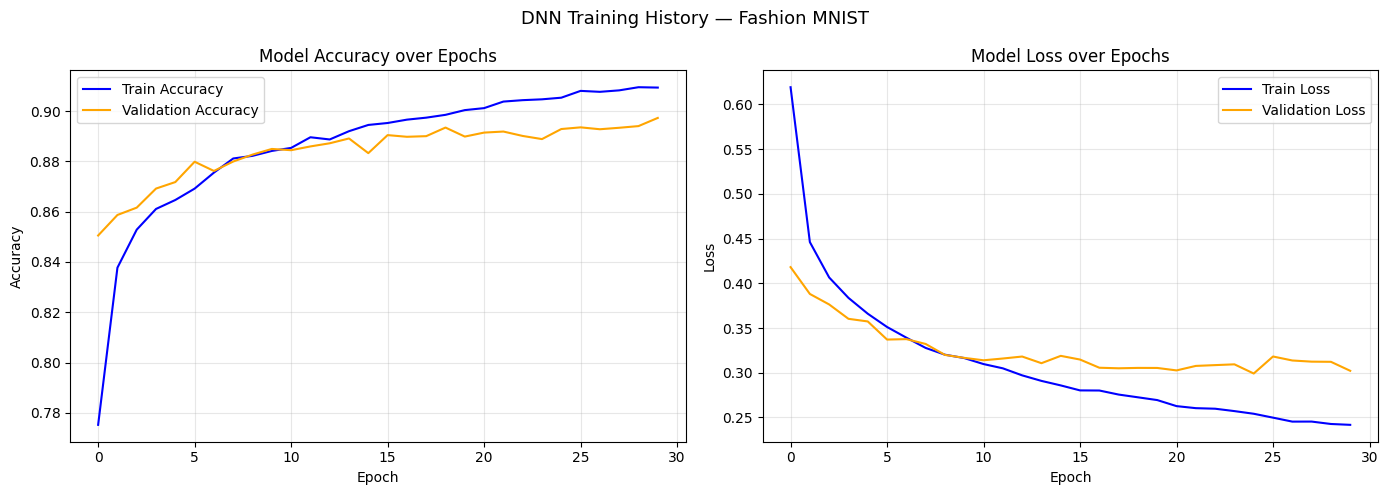

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history["accuracy"],     label="Train Accuracy",      color="blue")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
axes[0].set_title("Model Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history["loss"],     label="Train Loss",      color="blue")
axes[1].plot(history.history["val_loss"], label="Validation Loss", color="orange")
axes[1].set_title("Model Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("DNN Training History — Fashion MNIST", fontsize=13)
plt.tight_layout()
plt.show()

Test Accuracy: 88.85%
Test Loss    : 0.3283
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


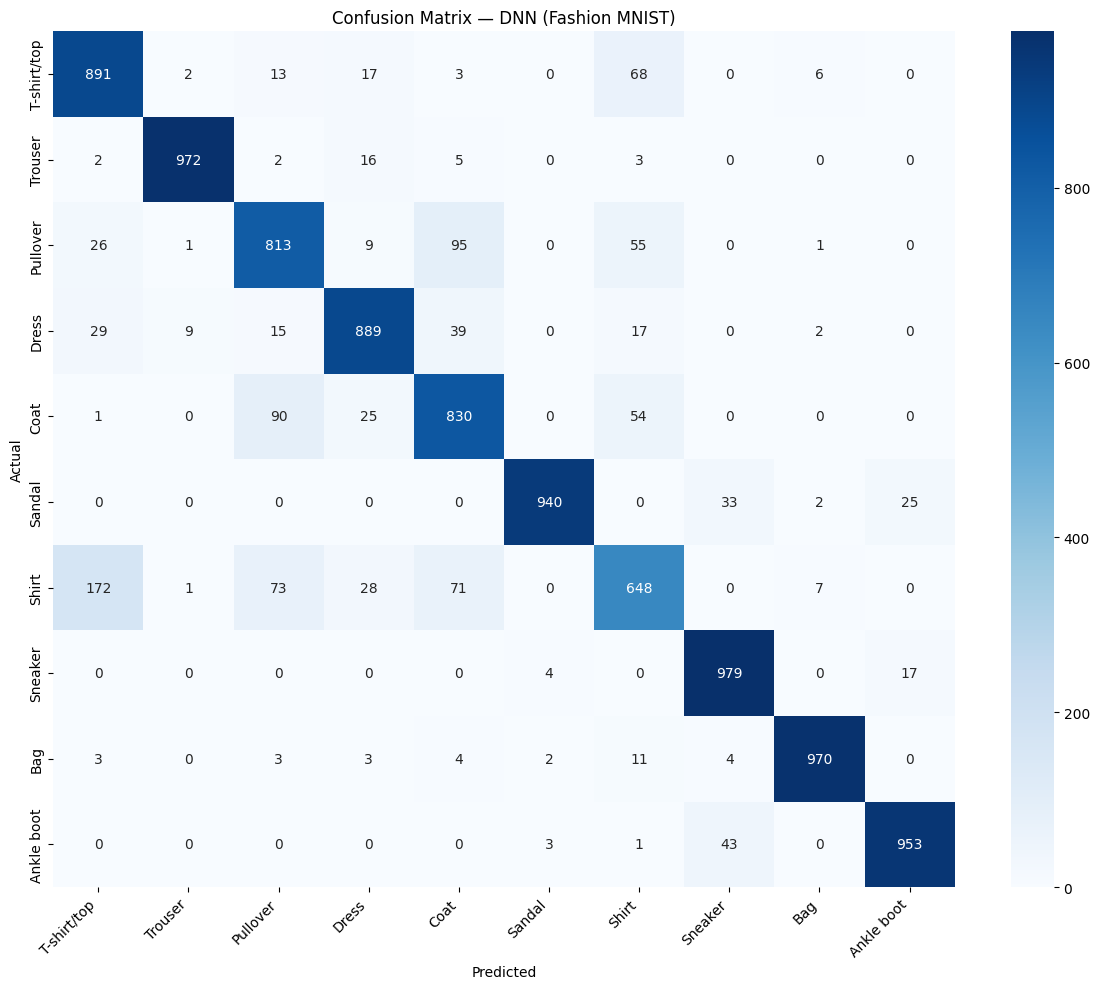


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.89      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.81      0.81      1000
       Dress       0.90      0.89      0.89      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.99      0.94      0.96      1000
       Shirt       0.76      0.65      0.70      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [8]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss    : {test_loss:.4f}")

# Predictions
y_pred_prob = model.predict(X_test_flat)
y_pred      = np.argmax(y_pred_prob, axis=1)  # get class with highest probability

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix — DNN (Fashion MNIST)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

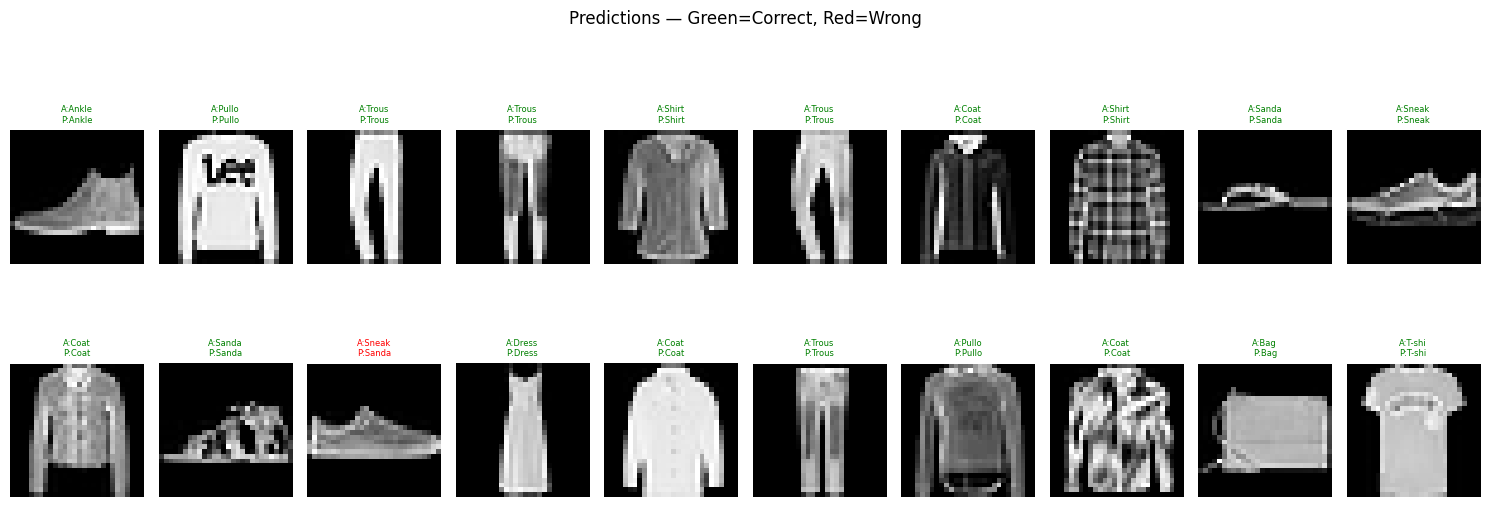

Per-class Accuracy:
  T-shirt/top    : 89.10%
  Trouser        : 97.20%
  Pullover       : 81.30%
  Dress          : 88.90%
  Coat           : 83.00%
  Sandal         : 94.00%
  Shirt          : 64.80%
  Sneaker        : 97.90%
  Bag            : 97.00%
  Ankle boot     : 95.30%


In [9]:
# Show sample predictions with actual vs predicted labels
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i], cmap="gray")

    actual    = class_names[y_test[i]]
    predicted = class_names[y_pred[i]]
    correct   = y_test[i] == y_pred[i]

    # Green title = correct, Red title = wrong
    plt.title(f"A:{actual[:5]}\nP:{predicted[:5]}",
              fontsize=6,
              color="green" if correct else "red")
    plt.axis("off")

plt.suptitle("Predictions — Green=Correct, Red=Wrong", fontsize=12)
plt.tight_layout()
plt.show()

# Print accuracy per class
print("Per-class Accuracy:")
for i, name in enumerate(class_names):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"  {name:15s}: {class_acc:.2f}%")